Which models you tried, metrics comparison, threshold selection rationale

In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path.cwd().parent.parent / "archive" / "labeled_data.csv")

df.head()

,amount,use_chip,errors,birth_year,birth_month,gender,yearly_income,total_debt,credit_score,num_credit_cards,...,card_on_dark_web,target,debt_to_income_ratio,years_to_retirement,is_retired,card_age_months,days_until_expiry,hour,dayofweek,is_night
0,-77.00,Swipe Transaction,NaN,1989,7,Female,48277.0,110153.0,740,4,...,0,0.0,2.281687,37,0,20,4563,0,4,1
1,14.57,Swipe Transaction,NaN,1971,6,Male,36853.0,112139.0,834,5,...,0,0.0,3.042873,19,0,52,5447,0,4,1
2,80.00,Swipe Transaction,NaN,1970,4,Male,34449.0,36540.0,686,3,...,0,0.0,1.060698,16,0,48,3772,0,4,1
3,46.41,Swipe Transaction,NaN,1968,5,Male,68362.0,96182.0,711,2,...,0,0.0,1.406951,18,0,6,3651,0,4,1
4,4.81,Swipe Transaction,NaN,1972,12,Female,52065.0,98613.0,828,5,...,0,0.0,1.894036,18,0,24,1519,0,4,1


In [2]:
df.columns

Index(['amount', 'use_chip', 'errors', 'birth_year', 'birth_month', 'gender',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
       'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued',
       'credit_limit', 'card_on_dark_web', 'target', 'debt_to_income_ratio',
       'years_to_retirement', 'is_retired', 'card_age_months',
       'days_until_expiry', 'hour', 'dayofweek', 'is_night'],
      dtype='object')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [4]:
X = df.drop(columns=["target"], inplace=False)
y = df["target"].astype(int)

In [5]:
# Check for missing values in target column
y.isna().sum()

np.int64(0)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # stratify to maintain class distribution in train and test sets
    )

In [7]:
# separate categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

bin_cols = [col for col in num_cols if X[col].nunique() == 2]
num_cols = [col for col in num_cols if col not in bin_cols]

print(bin_cols)
print(cat_cols)
print(num_cols)

['has_chip', 'is_retired', 'is_night']
Index(['use_chip', 'errors', 'gender', 'card_brand', 'card_type', 'expires'], dtype='object')
['amount', 'birth_year', 'birth_month', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'num_cards_issued', 'credit_limit', 'card_on_dark_web', 'debt_to_income_ratio', 'years_to_retirement', 'card_age_months', 'days_until_expiry', 'hour', 'dayofweek']


In [8]:
# scale numerical features
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [9]:
# encode (OHE) categorical features
from sklearn.preprocessing import OneHotEncoder

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

In [12]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'birth_year',
                                                   'birth_month',
                                                   'yearly_income',
                                                   'total_debt', 'credit_score',
                                                   'num_credit_cards',
                                                   'num_cards_issued',
                                                   'credit_limit',
                                                   'card_on_dark_web',
                                                   'debt_to_income_ratio',
                                                   'years_to_retirement',
                                                   'card_age_months',
                                                   'days_until_expiry', 'hour',
                                                   'dayofweek']),
                                                 ('bin', 'passthrough',
                                                  ['has_chip', 'is_retired',
                                                   'is_night']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['use_chip', 'errors', 'gender', 'card_brand', 'card_type', 'expires'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[1514388  265939]
 [    713    1953]]
              precision    recall  f1-score   support

           0       1.00      0.85      0.92   1780327
           1       0.01      0.73      0.01      2666

    accuracy                           0.85   1782993
   macro avg       0.50      0.79      0.47   1782993
weighted avg       1.00      0.85      0.92   1782993

ROC AUC: 0.8577035533772832


Recall: 0.71 - we already catch 71% of the fraud with the baseline model.

In [14]:
from sklearn.metrics import recall_score

threshold = 0.3  # tune
y_pred_adj = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_adj))

[[1083517  696810]
 [    267    2399]]


In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

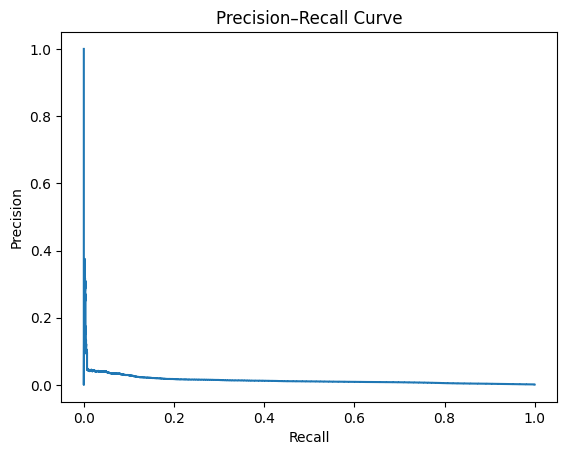

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.show()

Model is "confident" on a small subsset but becomes noisy quickly. Again, sign of highly imbalanced classification problem.

In [17]:
from sklearn.metrics import average_precision_score
print(average_precision_score(y_test, y_prob))

0.014301641536188918


LightGBM:

In [18]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced'
)

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

# Now LightGBM auto-detects them, no need to pass categorical_feature at all
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 10666, number of negative: 7121304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2402
[LightGBM] [Info] Number of data points in the train set: 7131970, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300)

In [19]:
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lgb))

[[1644288  136039]
 [    325    2341]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1780327
           1       0.02      0.88      0.03      2666

    accuracy                           0.92   1782993
   macro avg       0.51      0.90      0.50   1782993
weighted avg       1.00      0.92      0.96   1782993

ROC AUC: 0.9595326649136264


1. improvement for the roc auc: model captures more of nonlinear relationships between variables
2. higher fraud detection improved to 0.87
3. false positives (FP) dropped to 184,126

-> great overall improvement

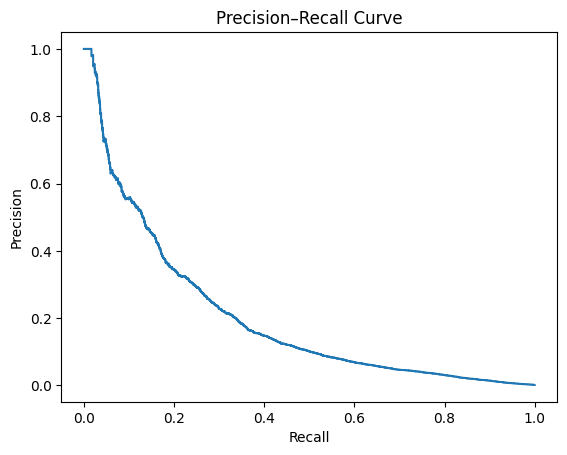

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgb)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.show()

In [21]:
aaa = pd.read_csv(Path.cwd().parent.parent / "archive" / "predictions.csv")
aaa.head()

,amount,use_chip,errors,birth_year,birth_month,gender,yearly_income,total_debt,credit_score,num_credit_cards,...,debt_to_income_ratio,years_to_retirement,is_retired,card_age_months,days_until_expiry,hour,dayofweek,is_night,preds,proba
0,200.00,Swipe Transaction,NaN,1967,5,Female,53350.0,128676.0,685,5,...,2.411921,15,False,69,5386,0,4,True,0,0.082802
1,77.00,Swipe Transaction,NaN,1989,7,Female,48277.0,110153.0,740,4,...,2.281687,37,False,20,4563,0,4,True,0,0.064032
2,261.58,Online Transaction,NaN,1973,7,Female,56467.0,66565.0,688,3,...,1.178830,22,False,15,3803,0,4,True,1,0.780069
3,10.74,Swipe Transaction,NaN,1928,9,Female,17150.0,375.0,807,6,...,0.021866,0,True,35,5051,0,4,True,0,0.010256
4,1.09,Swipe Transaction,NaN,1953,3,Male,20577.0,60152.0,825,4,...,2.923264,2,False,70,3833,0,4,True,0,0.009782


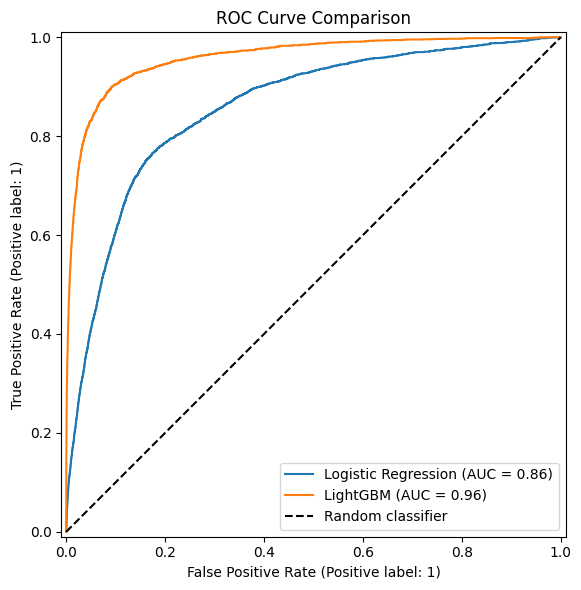

In [22]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Plot both models on the same axes
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, ax=ax, name="LightGBM")

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

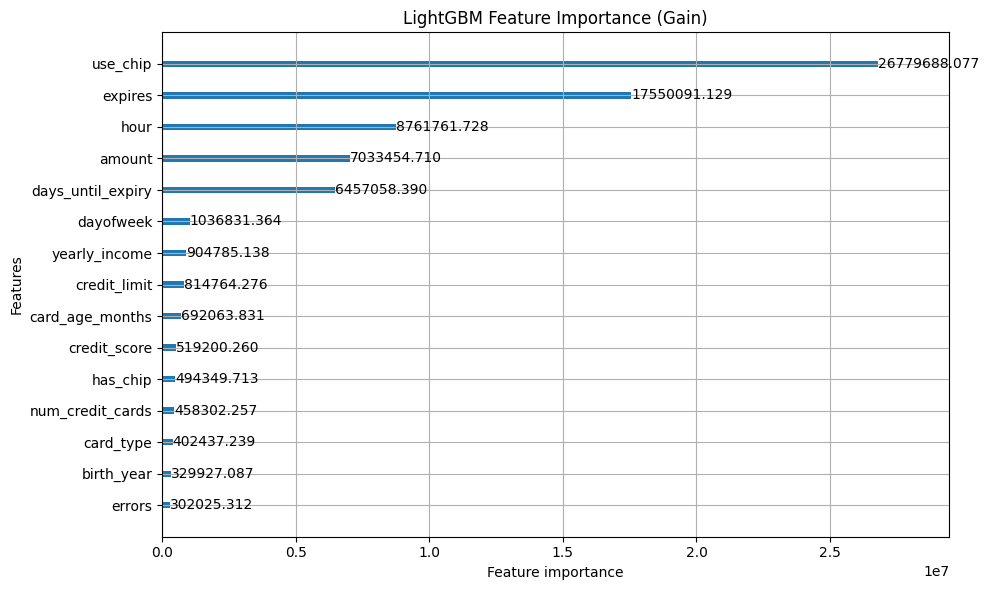

In [23]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, 
                    max_num_features=15,      # top 15 features
                    importance_type='gain',   # 'gain' is more meaningful than 'split'
                    figsize=(10, 6),
                    title='LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

/var/folders/q7/3_x5zwtn1tz73121ks83471m0000gn/T/ipykernel_33668/1010227552.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


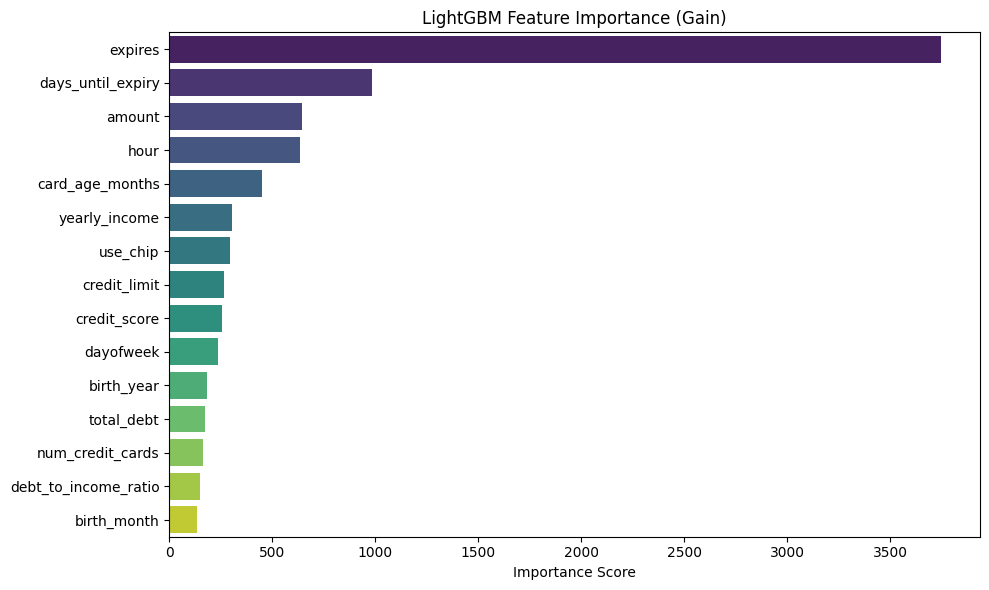

In [25]:
import pandas as pd
import seaborn as sns

# Extract feature importances
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('LightGBM Feature Importance (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()